# 0. Setup: imports, drive \& paths

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
import json
import re
import time
import numpy as np
import pandas as pd

from tqdm import tqdm
from openai import OpenAI, RateLimitError
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report

Mounted at /content/drive


In [2]:
BASE_DIR = "/content/drive/MyDrive/NLP_Projects/03_DrugReview/01_R0/00_labelling"
print("Files in BASE_DIR:", os.listdir(BASE_DIR))

RAW_DATA_PATH = os.path.join(BASE_DIR, "output/drugscom_plus_ai_labels.csv")

Files in BASE_DIR: ['data', 'output', 'DrugReview_CleanComments.ipynb', 'DrugName 4omini_Labeling.ipynb', 'AI_AI_Agreement_Check_Colab.ipynb', 'LabellingAnalysis.ipynb']


# 1. Load dataset

In [3]:
# Load the raw data from our config path into a generic DataFrame
df = pd.read_csv(RAW_DATA_PATH, index_col = 0)
print(f"Loaded raw data with {df.shape[0]} rows.")

Loaded raw data with 102061 rows.


In [4]:
df.head()

,drugName,ingredient_norm,ingredient_set_key,n_ingredients,condition,condition_norm,review,text_norm,rating,date,...,ai_p_very_positive,ai_efficacy,ai_safety,ai_burden,ai_cost,ai_model,ai_seed,ai_temp,ai_ts_utc,ai_raw_json
uniqueID,,,,,,,,,,,,,,,,,,,,,
124923,Allopurinol,allopurinol,allopurinol,1,Gout,gout,"""\r\n300 mg and colcris to reduce anything the...",""" 300 mg and colcris to reduce anything the mi...",3,18-Feb-17,...,0.0,POSITIVE,NEGATIVE,NEGATIVE,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612186+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."
127676,Phentermine,phentermine,phentermine,1,Weight Loss,weight loss,"""\r\nA previous poster Ryan Smith said &quot;I...",""" a previous poster ryan smith said ""i've seen...",10,16-Apr-17,...,0.5,POSITIVE,NEUTRAL,POSITIVE,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612311+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."
81819,Liraglutide,liraglutide,liraglutide,1,Obesity,obesity,""" began with the minimum 0.6 mg dose of Saxend...",""" began with the minimum 0.6 mg dose of saxend...",10,18-Mar-17,...,0.1,POSITIVE,NEGATIVE,NEUTRAL,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612391+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."
170223,Quetiapine,quetiapine,quetiapine,1,Bipolar Disorde,bipolar disorde,""" Caused depression and negative, self defeati...",""" caused depression and negative, self defeati...",1,25-Aug-16,...,0.0,NEGATIVE,NEGATIVE,NEGATIVE,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612469+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."
48454,Ethinyl estradiol / levonorgestrel,ethinyl estradiol / levonorgestrel,ethinyl estradiol / levonorgestrel,2,Birth Control,birth control,""" Ever since I started taking this birth contr...",""" ever since i started taking this birth contr...",1,30-Oct-17,...,0.0,NEGATIVE,NEGATIVE,NEGATIVE,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612538+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."


Rating-derived 5-class label distribution:
sentiment_5
NEGATIVE          7465
NEUTRAL           9547
POSITIVE         18826
VERY_NEGATIVE    17359
VERY_POSITIVE    48864
Name: count, dtype: int64

Computing entropy for all reviews...

Entropy Statistics:
count    102061.000000
mean          0.710606
std           0.165346
min          -0.000000
25%           0.586135
50%           0.741594
75%           0.835234
max           1.000000
Name: entropy, dtype: float64

Entropy quartiles:
0.25    0.586135
0.50    0.741594
0.75    0.835234
Name: entropy, dtype: float64


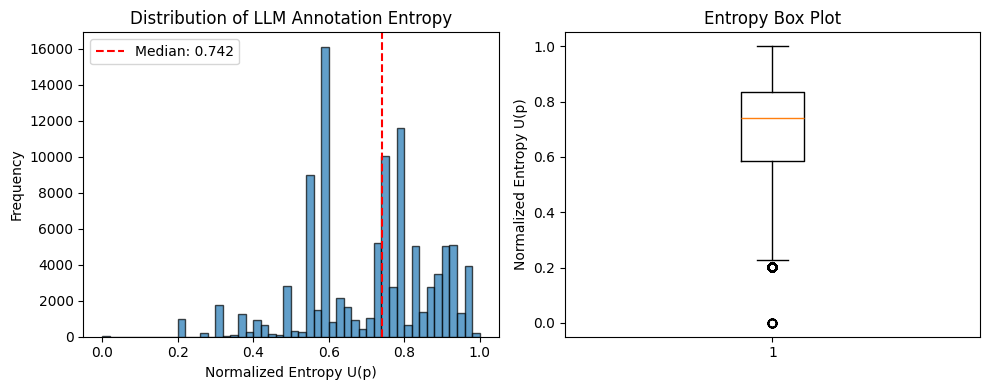

/tmp/ipykernel_11406/3865179898.py:123: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreement_by_entropy = df.groupby('entropy_quartile').agg({



Rating vs AI Agreement by Entropy Quartile:
                  rating_vs_ai
entropy_quartile              
Q1 (Low)                 0.672
Q2                       0.693
Q3                       0.389
Q4 (High)                0.295

Spearman correlation (Entropy vs Rating-AI Agreement): ρ = -0.333, p = 0.00e+00


/tmp/ipykernel_11406/3865179898.py:155: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreement_data = df.groupby('entropy_quartile')['rating_vs_ai'].mean()


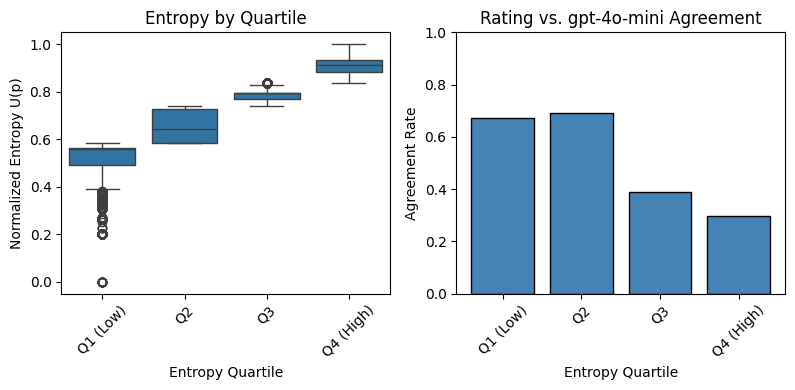


Sample High-Entropy Reviews (U > 0.8):

Entropy: 1.000
Rating-derived: VERY_POSITIVE, AI: VERY_NEGATIVE
Probs: VNeg=0.20, Neg=0.20, Neu=0.20, Pos=0.20, VPos=0.20
Review snippet: "Holy hell I&#039;m feeling weird. I give this medication a high review because it honestly does work but the sides effects are wild!!!!! I&#039;m on the 6th day of 7 and just took a pregnancy test be...
------------------------------------------------------------

Entropy: 1.000
Rating-derived: NEUTRAL, AI: VERY_NEGATIVE
Probs: VNeg=0.20, Neg=0.20, Neu=0.20, Pos=0.20, VPos=0.20
Review snippet: "I was on Microgestin fe 1/20 for 4 years. In the beginning everything was fine.  My acne from high school went away, I didn&#039;t have anymore cramps, and very light periods.  Now that i&#039;m on m...
------------------------------------------------------------

Entropy: 1.000
Rating-derived: POSITIVE, AI: VERY_NEGATIVE
Probs: VNeg=0.20, Neg=0.20, Neu=0.20, Pos=0.20, VPos=0.20
Review snippet: "I started taking the me

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, kendalltau

# ============================================================
# 0. DERIVE 5-CLASS SENTIMENT FROM 1-10 RATING
# ============================================================

# Assuming the rating column is called 'rating' (adjust if different)
# Mapping: 1-2 -> very negative, 3-4 -> negative, 5-6 -> neutral, 7-8 -> positive, 9-10 -> very positive

def map_rating_to_sentiment(rating):
    """Map 1-10 rating to 5-class ordinal sentiment"""
    if rating in [1, 2]:
        return 'VERY_NEGATIVE'
    elif rating in [3, 4]:
        return 'NEGATIVE'
    elif rating in [5, 6]:
        return 'NEUTRAL'
    elif rating in [7, 8]:
        return 'POSITIVE'
    elif rating in [9, 10]:
        return 'VERY_POSITIVE'
    else:
        return None

# Apply mapping (adjust 'rating' to your actual column name)
df['sentiment_5'] = df['rating'].apply(map_rating_to_sentiment)

print("Rating-derived 5-class label distribution:")
print(df['sentiment_5'].value_counts().sort_index())

# ============================================================
# 1. COMPUTE ENTROPY FROM PROBABILITY COLUMNS
# ============================================================

# Assuming columns are: ai_p_very_negative, ai_p_negative, ai_p_neutral, ai_p_positive, ai_p_very_positive
prob_cols = [
    'ai_p_very_negative',
    'ai_p_negative',
    'ai_p_neutral',
    'ai_p_positive',
    'ai_p_very_positive'
]

def shannon_entropy(row, cols=prob_cols):
    """Compute normalized Shannon entropy H ∈ [0,1]"""
    # Convert to numpy array explicitly
    p = np.array([row[col] for col in cols], dtype=float)
    # Remove zeros to avoid log(0)
    p = p[p > 0]
    if len(p) == 0:
        return 0.0
    # Use numpy's log with explicit array
    H = -np.sum(p * np.log(p))
    H_normalized = H / np.log(5)  # Normalize by log(5) for 5 classes
    return float(H_normalized)

# Compute entropy for each row
print("\nComputing entropy for all reviews...")
df['entropy'] = df.apply(shannon_entropy, axis=1)

print("\nEntropy Statistics:")
print(df['entropy'].describe())
print(f"\nEntropy quartiles:")
print(df['entropy'].quantile([0.25, 0.5, 0.75]))

# ============================================================
# 2. ENTROPY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['entropy'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Normalized Entropy U(p)')
plt.ylabel('Frequency')
plt.title('Distribution of LLM Annotation Entropy')
plt.axvline(df['entropy'].median(), color='red', linestyle='--', label=f'Median: {df["entropy"].median():.3f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(df['entropy'], vert=True)
plt.ylabel('Normalized Entropy U(p)')
plt.title('Entropy Box Plot')
plt.tight_layout()
plt.savefig('entropy_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 3. LABEL DISAGREEMENT vs ENTROPY
# ============================================================

# Assuming you have these label columns:
# sentiment_5 = rating-derived 5-class labels (just created)
# ai_sent5_hard = gpt-4o-mini hard labels
# aspect_5class = aspect-derived 5-class labels (if available)

# Check if aspect labels exist
has_aspect = 'aspect_5class' in df.columns

# Compute label agreement
df['rating_vs_ai'] = (df['sentiment_5'] == df['ai_sent5_hard']).astype(int)
if has_aspect:
    df['rating_vs_aspect'] = (df['sentiment_5'] == df['aspect_5class']).astype(int)
    df['ai_vs_aspect'] = (df['ai_sent5_hard'] == df['aspect_5class']).astype(int)

# Entropy quartiles
df['entropy_quartile'] = pd.qcut(df['entropy'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])

# Agreement by entropy quartile
if has_aspect:
    agreement_by_entropy_full = df.groupby('entropy_quartile').agg({
        'rating_vs_ai': 'mean',
        'rating_vs_aspect': 'mean',
        'ai_vs_aspect': 'mean'
    })
    print("\nLabel Agreement by Entropy Quartile:")
    print(agreement_by_entropy_full.round(3))
else:
    agreement_by_entropy = df.groupby('entropy_quartile').agg({
        'rating_vs_ai': 'mean',
    })
    print("\nRating vs AI Agreement by Entropy Quartile:")
    print(agreement_by_entropy.round(3))

# ============================================================
# 4. CORRELATION: ENTROPY vs DISAGREEMENT
# ============================================================

# Point-biserial correlation equivalent (Spearman on binary)
rho, p_val = spearmanr(df['entropy'], df['rating_vs_ai'])
print(f"\nSpearman correlation (Entropy vs Rating-AI Agreement): ρ = {rho:.3f}, p = {p_val:.2e}")

if has_aspect:
    rho2, p_val2 = spearmanr(df['entropy'], df['ai_vs_aspect'])
    print(f"Spearman correlation (Entropy vs AI-Aspect Agreement): ρ = {rho2:.3f}, p = {p_val2:.2e}")

# ============================================================
# 5. VISUALIZATION: ENTROPY vs AGREEMENT
# ============================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.boxplot(data=df, x='entropy_quartile', y='entropy')
plt.xlabel('Entropy Quartile')
plt.ylabel('Normalized Entropy U(p)')
plt.title('Entropy by Quartile')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
agreement_data = df.groupby('entropy_quartile')['rating_vs_ai'].mean()
plt.bar(range(4), agreement_data.values, color='steelblue', edgecolor='black')
plt.xticks(range(4), agreement_data.index, rotation=45)
plt.ylabel('Agreement Rate')
plt.xlabel('Entropy Quartile')
plt.title('Rating vs. gpt-4o-mini Agreement')
plt.ylim([0, 1])

if has_aspect:
    plt.subplot(1, 3, 3)
    agreement_data2 = df.groupby('entropy_quartile')['ai_vs_aspect'].mean()
    plt.bar(range(4), agreement_data2.values, color='coral', edgecolor='black')
    plt.xticks(range(4), agreement_data2.index, rotation=45)
    plt.ylabel('Agreement Rate')
    plt.xlabel('Entropy Quartile')
    plt.title('gpt-4o-mini vs. Aspect Agreement')
    plt.ylim([0, 1])

plt.tight_layout()
plt.savefig('entropy_vs_agreement.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 6. HIGH ENTROPY EXAMPLES
# ============================================================

print("\n" + "="*60)
print("Sample High-Entropy Reviews (U > 0.8):")
print("="*60)

high_entropy = df[df['entropy'] > 0.8].sort_values('entropy', ascending=False).head(5)
for idx, row in high_entropy.iterrows():
    print(f"\nEntropy: {row['entropy']:.3f}")
    print(f"Rating-derived: {row['sentiment_5']}, AI: {row['ai_sent5_hard']}")
    if has_aspect:
        print(f"Aspect-derived: {row['aspect_5class']}")
    print(f"Probs: VNeg={row['ai_p_very_negative']:.2f}, Neg={row['ai_p_negative']:.2f}, "
          f"Neu={row['ai_p_neutral']:.2f}, Pos={row['ai_p_positive']:.2f}, VPos={row['ai_p_very_positive']:.2f}")
    if 'review' in row:
        print(f"Review snippet: {row['review'][:200]}...")
    print("-" * 60)

In [6]:
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy
import numpy as np
import pandas as pd

CLASS_ORDER = [
    "VERY_NEGATIVE",
    "NEGATIVE",
    "NEUTRAL",
    "POSITIVE",
    "VERY_POSITIVE",
]

def label_distribution(series, class_order=CLASS_ORDER):
    counts = series.value_counts().reindex(class_order, fill_value=0)
    probs = counts / counts.sum()
    return counts, probs

def js_metrics(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = p / p.sum()
    q = q / q.sum()

    # SciPy returns Jensen-Shannon distance = sqrt(JS divergence)
    js_distance = jensenshannon(p, q)  # natural-log convention by default
    js_divergence = js_distance ** 2

    # Manual check
    m = 0.5 * (p + q)
    js_divergence_manual = 0.5 * entropy(p, m) + 0.5 * entropy(q, m)

    return js_distance, js_divergence, js_divergence_manual

rating_counts, rating_probs = label_distribution(df["sentiment_5"])
ai_counts, ai_probs = label_distribution(df["ai_sent5_hard"])

print("Rating-derived counts:")
print(rating_counts)
print("\nRating-derived proportions:")
print(rating_probs.round(4))

print("\nHolistic LLM counts:")
print(ai_counts)
print("\nHolistic LLM proportions:")
print(ai_probs.round(4))

js_dist, js_div, js_div_manual = js_metrics(rating_probs, ai_probs)

print("\nRating-derived vs holistic LLM:")
print(f"Jensen-Shannon distance:   {js_dist:.3f}")
print(f"Jensen-Shannon divergence: {js_div:.3f}")
print(f"Manual divergence check:   {js_div_manual:.3f}")

if "aspect_5class" in df.columns:
    aspect_counts, aspect_probs = label_distribution(df["aspect_5class"])

    print("\nAspect-derived counts:")
    print(aspect_counts)
    print("\nAspect-derived proportions:")
    print(aspect_probs.round(4))

    for name, probs in [
        ("Rating-derived vs aspect-derived", aspect_probs),
        ("Holistic LLM vs aspect-derived", aspect_probs),
    ]:
        pass

    js_dist_ra, js_div_ra, _ = js_metrics(rating_probs, aspect_probs)
    js_dist_aa, js_div_aa, _ = js_metrics(ai_probs, aspect_probs)

    print("\nRating-derived vs aspect-derived:")
    print(f"Jensen-Shannon distance:   {js_dist_ra:.3f}")
    print(f"Jensen-Shannon divergence: {js_div_ra:.3f}")

    print("\nHolistic LLM vs aspect-derived:")
    print(f"Jensen-Shannon distance:   {js_dist_aa:.3f}")
    print(f"Jensen-Shannon divergence: {js_div_aa:.3f}")


Rating-derived counts:
sentiment_5
VERY_NEGATIVE    17359
NEGATIVE          7465
NEUTRAL           9547
POSITIVE         18826
VERY_POSITIVE    48864
Name: count, dtype: int64

Rating-derived proportions:
sentiment_5
VERY_NEGATIVE    0.1701
NEGATIVE         0.0731
NEUTRAL          0.0935
POSITIVE         0.1845
VERY_POSITIVE    0.4788
Name: count, dtype: float64

Holistic LLM counts:
ai_sent5_hard
VERY_NEGATIVE    24206
NEGATIVE         12873
NEUTRAL           1838
POSITIVE         35397
VERY_POSITIVE    27747
Name: count, dtype: int64

Holistic LLM proportions:
ai_sent5_hard
VERY_NEGATIVE    0.2372
NEGATIVE         0.1261
NEUTRAL          0.0180
POSITIVE         0.3468
VERY_POSITIVE    0.2719
Name: count, dtype: float64

Rating-derived vs holistic LLM:
Jensen-Shannon distance:   0.218
Jensen-Shannon divergence: 0.047
Manual divergence check:   0.047


In [7]:
CLASS_ORDER = ["VERY_NEGATIVE", "NEGATIVE", "NEUTRAL", "POSITIVE", "VERY_POSITIVE"]

def label_dist(series):
    counts = series.value_counts().reindex(CLASS_ORDER, fill_value=0)
    return (counts / counts.sum()).values

# --- Reconstruct aspect-derived 5-class labels (2:1:1:2 rule) ---
sent_map = {"NEGATIVE": -1, "NEUTRAL": 0, "POSITIVE": 1}

v_eff  = df["ai_efficacy"].map(sent_map)
v_saf  = df["ai_safety"].map(sent_map)
v_bur  = df["ai_burden"].map(sent_map)
v_cost = df["ai_cost"].map(sent_map)

s = 2*v_eff + 1*v_saf + 1*v_bur + 2*v_cost  # score in [-6, 6]

def score_to_label(s):
    if s >= 5:   return "VERY_POSITIVE"
    elif s >= 2: return "POSITIVE"
    elif s >= -1: return "NEUTRAL"
    elif s >= -4: return "NEGATIVE"
    else:         return "VERY_NEGATIVE"

df["aspect_5class"] = s.map(score_to_label)

# --- Get distributions ---
p_rating   = label_dist(df["sentiment_5"])      # adjust col name if needed
p_holistic = label_dist(df["ai_sent5_hard"])
p_aspect   = label_dist(df["aspect_5class"])

# --- Compute JS distances ---
js_rating_holistic = jensenshannon(p_rating,   p_holistic)
js_aspect_rating   = jensenshannon(p_aspect,   p_rating)
js_aspect_holistic = jensenshannon(p_aspect,   p_holistic)

print(f"JS distance — rating vs holistic LLM:  {js_rating_holistic:.3f}")
print(f"JS distance — aspect vs rating:         {js_aspect_rating:.3f}")
print(f"JS distance — aspect vs holistic LLM:   {js_aspect_holistic:.3f}")

print("\nAspect-derived class distribution:")
for cls, p in zip(CLASS_ORDER, p_aspect):
    print(f"  {cls:<16}: {p:.4f}")

JS distance — rating vs holistic LLM:  0.218
JS distance — aspect vs rating:         0.493
JS distance — aspect vs holistic LLM:   0.440

Aspect-derived class distribution:
  VERY_NEGATIVE   : 0.0178
  NEGATIVE        : 0.2842
  NEUTRAL         : 0.2292
  POSITIVE        : 0.4491
  VERY_POSITIVE   : 0.0196
